# Under Construction

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
#import cftime
import nc_time_axis
import sys
import calendar
import re
sys.path.append('C:/Users/madel/Code/GeoNorth/Observational_data')

from obs_utils import *

## Variable and Site settings

In [2]:
# Input the site ID and variables here

site = "TVC"         # BC, TVC, HC, IQ, SC

# SOIL TEMP

In [3]:
vari = "TSOI"  #SNOW_DEPTH, H2OSOI, TSOI
depths = [0.10, 0.20, 0.30, 0.46]
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}"
times, values = pull_files(directory_path)

check that time shape is the same or turning it into a dataset will be tricky

In [92]:
check_shapes(times)

All arrays match: (186326,)


In [93]:
data_2d = np.column_stack(values)

print(data_2d.shape)

(186326, 4)


In [94]:
ds_obs = make_obs_ds(vari, data_2d, times[0], site, "°C", depths)
ds_obs

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 186326, depth: 4)
Coordinates:
  * time     (time) object 1MB 2003-01-01 00:00:00 ... 2014-05-01 00:00:00
  * depth    (depth) float64 32B 0.1 0.2 0.3 0.46
Data variables:
    TSOI     (time, depth) float64 6MB -2.195 -1.764 -5.541 ... -6.266 -6.691
Attributes:
    site:     TVC
    source:   GWF observed

In [95]:
def plot_soil_temp_depths(ds):
    fig, ax = plt.subplots(figsize=(14, 5))
    for depth in ds["depth"].values:
        ax.plot(ds["time"].values, ds[f"{vari}"].sel(depth=depth).values, label=f"{depth} m")
    ax.legend()
    plt.show()

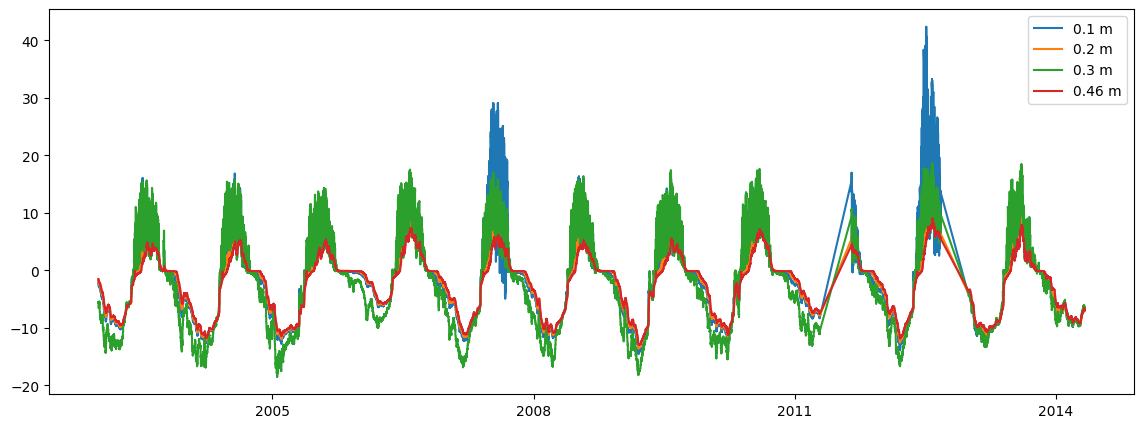

In [96]:
plot_soil_temp_depths(ds_obs)

In [97]:
ds_obs

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 186326, depth: 4)
Coordinates:
  * time     (time) object 1MB 2003-01-01 00:00:00 ... 2014-05-01 00:00:00
  * depth    (depth) float64 32B 0.1 0.2 0.3 0.46
Data variables:
    TSOI     (time, depth) float64 6MB -2.195 -1.764 -5.541 ... -6.266 -6.691
Attributes:
    site:     TVC
    source:   GWF observed

In [98]:
ds_obs.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\madel\\Code\\GeoNorth\\Observational_data\\TVC_obs\\processed\\TSOI\\TVC_TSOI.nc'

In [99]:

# Load — one line back to xarray
ds_test = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")
ds_test

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 186326, depth: 4)
Coordinates:
  * time     (time) object 1MB 2003-01-01 00:00:00 ... 2014-05-01 00:00:00
  * depth    (depth) float64 32B 0.1 0.2 0.3 0.46
Data variables:
    TSOI     (time, depth) float64 6MB ...
Attributes:
    site:     TVC
    source:   GWF observed

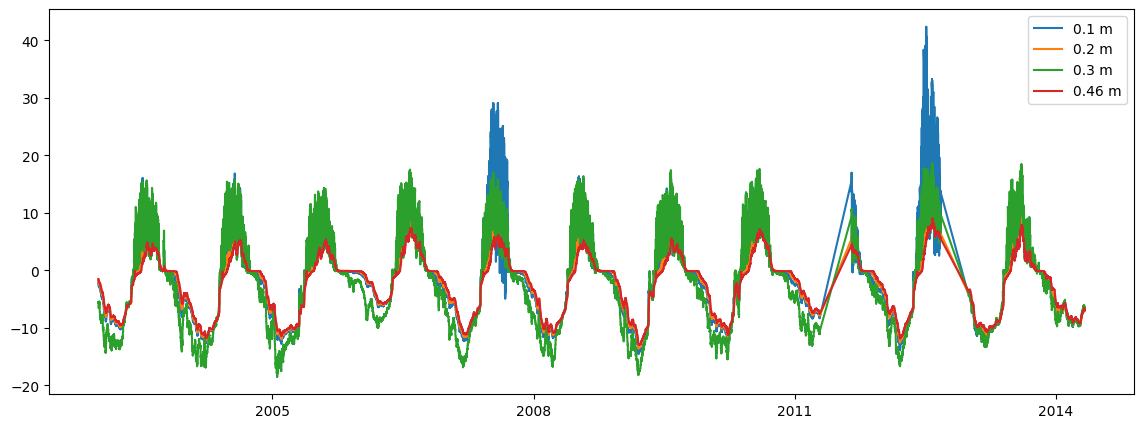

In [100]:
plot_soil_temp_depths(ds_test)

# SOIL MOISTURE

In [101]:
vari = "H2OSOI"  #SNOW_DEPTH, H2OSOI, TSOI
depths = [0.08, 0.15]
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}"
times, values = pull_files(directory_path)

In [102]:
check_shapes(times)

All arrays match: (186326,)


In [103]:
data_2d = np.column_stack(values)

print(data_2d.shape)

(186326, 2)


In [104]:
ds_obs = make_obs_ds(vari, data_2d, times[0], site, "mm3/mm3", depths)
ds_obs

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 186326, depth: 2)
Coordinates:
  * time     (time) object 1MB 2003-01-01 00:00:00 ... 2014-05-01 00:00:00
  * depth    (depth) float64 16B 0.08 0.15
Data variables:
    H2OSOI   (time, depth) float64 3MB 0.154 0.109 0.154 ... 0.097 0.142 0.097
Attributes:
    site:     TVC
    source:   GWF observed

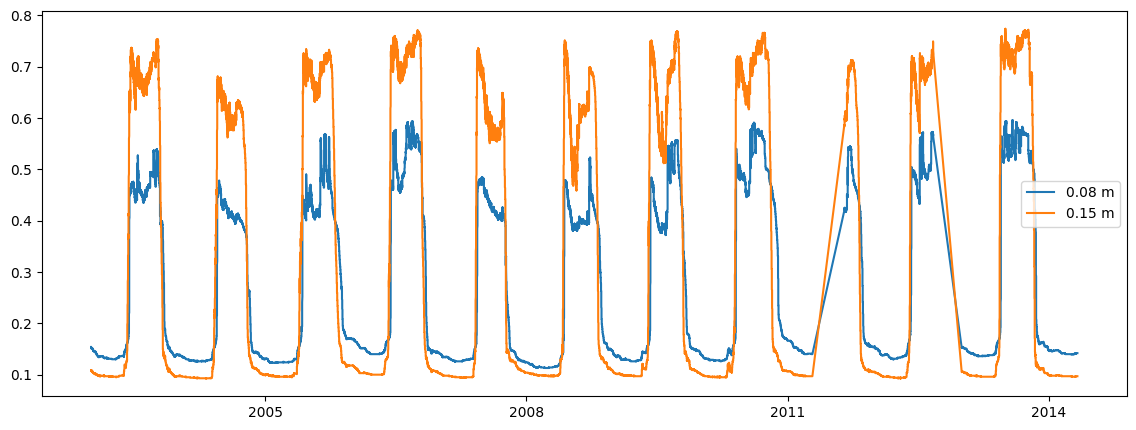

In [105]:
plot_soil_temp_depths(ds_obs)

In [106]:
ds_obs

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 186326, depth: 2)
Coordinates:
  * time     (time) object 1MB 2003-01-01 00:00:00 ... 2014-05-01 00:00:00
  * depth    (depth) float64 16B 0.08 0.15
Data variables:
    H2OSOI   (time, depth) float64 3MB 0.154 0.109 0.154 ... 0.097 0.142 0.097
Attributes:
    site:     TVC
    source:   GWF observed

In [107]:
ds_obs.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\madel\\Code\\GeoNorth\\Observational_data\\TVC_obs\\processed\\H2OSOI\\TVC_H2OSOI.nc'

In [108]:

# Load — one line back to xarray
ds_test = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")
ds_test

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 186326, depth: 2)
Coordinates:
  * time     (time) object 1MB 2003-01-01 00:00:00 ... 2014-05-01 00:00:00
  * depth    (depth) float64 16B 0.08 0.15
Data variables:
    H2OSOI   (time, depth) float64 3MB ...
Attributes:
    site:     TVC
    source:   GWF observed

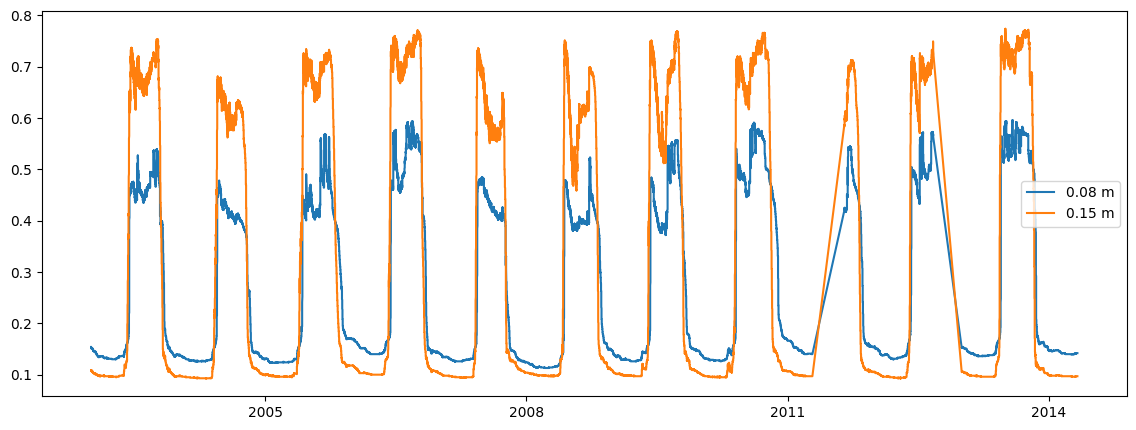

In [109]:
plot_soil_temp_depths(ds_test)

# SNOW DEPTH

In [125]:
vari = "SNOW_DEPTH"  #SNOW_DEPTH, H2OSOI, TSOI
depths = [1, 2]
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}"
times, values = pull_files(directory_path)

In [126]:
check_shapes(times)

Index 0: (87590,)
Index 1: (34844,)


In [131]:
print(times[0][0], times[0][-1])
print(times[1][0], times[1][-1])

2002-01-01 00:00:00 2007-01-01 00:00:00
2012-01-01 00:00:00 2014-04-26 00:00:00


In [133]:
time_concat = np.concatenate((times[0], times[1])) 
value_concat = np.concatenate((values[0], values[1])) 

In [135]:
ds = xr.Dataset(
        {"snow_depth": (["time"], value_concat, {"units": "cm"})},
        coords={"time": time_concat},
        attrs={"site": f"site", "source": "GWF observed"}
    )

In [136]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 122434)
Coordinates:
  * time        (time) object 979kB 2002-01-01 00:00:00 ... 2014-04-26 00:00:00
Data variables:
    snow_depth  (time) float64 979kB 258.0 256.0 252.0 ... 818.0 816.0 814.0
Attributes:
    site:     site
    source:   GWF observed

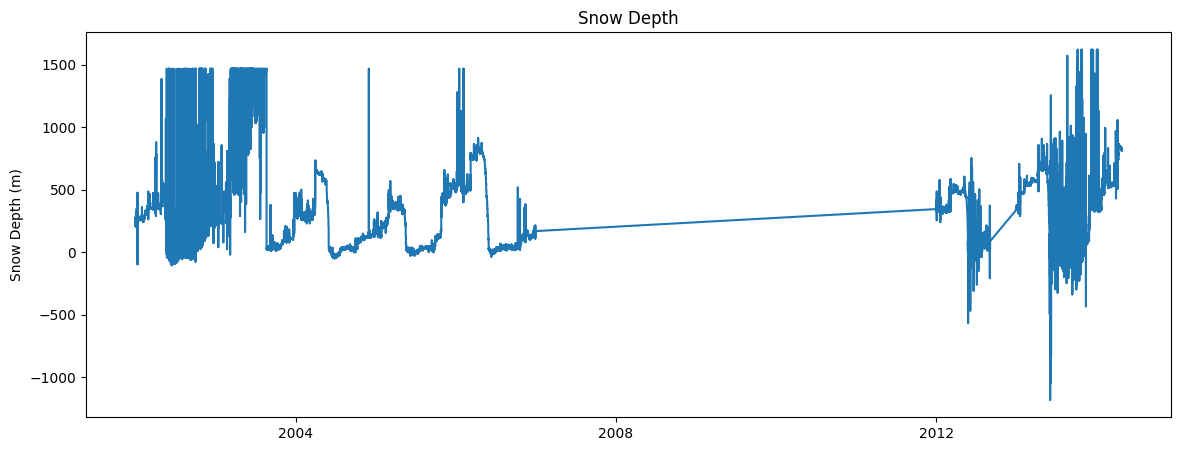

In [137]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ds["time"].values, ds["snow_depth"].values)
ax.set_ylabel("Snow Depth (m)")
ax.set_title("Snow Depth")
plt.show()

In [138]:
ds.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")


In [139]:

# Load — one line back to xarray
ds_test = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")
ds_test

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 122434)
Coordinates:
  * time        (time) object 979kB 2002-01-01 00:00:00 ... 2014-04-26 00:00:00
Data variables:
    snow_depth  (time) float64 979kB ...
Attributes:
    site:     site
    source:   GWF observed

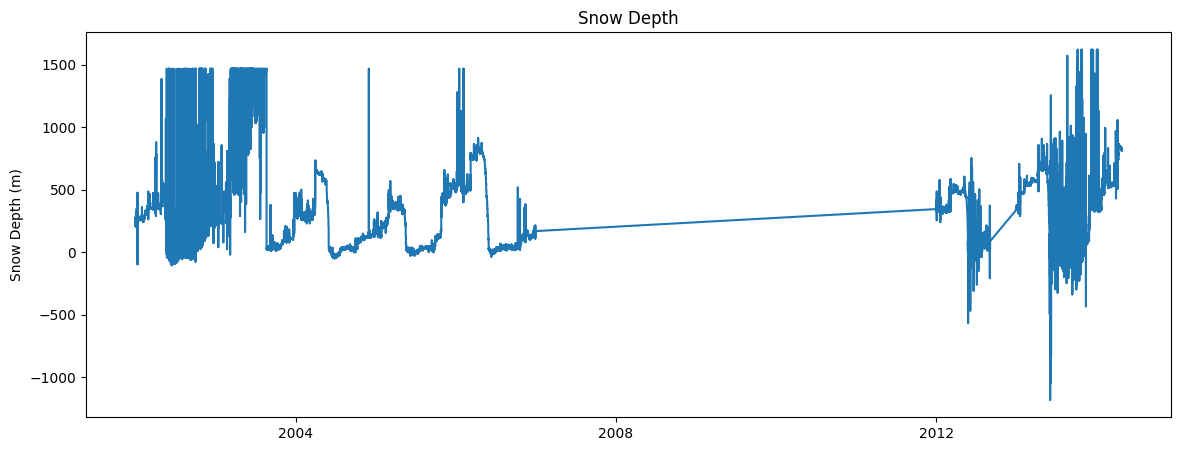

In [140]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ds_test["time"].values, ds_test["snow_depth"].values)
ax.set_ylabel("Snow Depth (m)")
ax.set_title("Snow Depth")
plt.show()